In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB , BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

In [ ]:
train_data = fetch_20newsgroups(
    subset = "train",
    remove=("header", "footers","quotes")
)

test_data = fetch_20newsgroups(
    subset = "train",
    remove = ("headers", "footers", "quotes")
)

In [ ]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target
class_names = train_data.target_names

In [ ]:
print("Training Documents:",len(X_train_text))
print("Testing Documents:", len(X_test_text))
print("Number of classes:", len(class_names))

Training Documents: 11314
Testing Documents: 11314
Number of classes: 20


In [ ]:
vectorizer = CountVectorizer(
    stop_words ="english",
    min_df = 2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [ ]:
X_train = vectorizer. fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)


In [ ]:
print("Training Feature matrix: ",X_train.shape)
print("Training feature matrix: ",X_test.shape)

Training Feature matrix:  (11314, 41233)
Training feature matrix:  (11314, 41233)


In [ ]:
mnb = MultinomialNB()
mnb.fit(
    X_train,
    y_train
    )
y_pred_mnb = mnb.predict(X_test)

In [ ]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary=binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)

In [ ]:
bnb = BernoulliNB()
bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb = bnb.predict(
    X_test_binary
    )

In [ ]:
acc_mnb = accuracy_score(y_test, y_pred_mnb)
prec_mnb = precision_score(y_test, y_pred_mnb, average='weighted')
rec_mnb = recall_score(y_test, y_pred_mnb, average='weighted')
f1_mnb = f1_score(y_test, y_pred_mnb, average='weighted')


acc_bnb = accuracy_score(y_test, y_pred_bnb)
prec_bnb = precision_score(y_test, y_pred_bnb, average='weighted')
rec_bnb = recall_score(y_test, y_pred_bnb, average='weighted')
f1_bnb = f1_score(y_test, y_pred_bnb, average='weighted')

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Multinomial NB": [acc_mnb, prec_mnb, rec_mnb, f1_mnb],
    "Bernoulli NB": [acc_bnb, prec_bnb, rec_bnb, f1_bnb]
})

print(results)

      Metric  Multinomial NB  Bernoulli NB
0   Accuracy        0.845766      0.671734
1  Precision        0.860734      0.819071
2     Recall        0.845766      0.671734
3   F1 Score        0.846224      0.681946


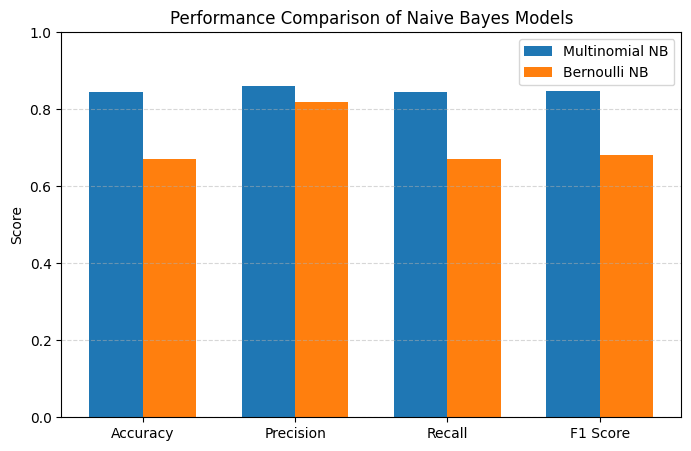

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

mnb_scores = [acc_mnb, prec_mnb, rec_mnb, f1_mnb]
bnb_scores = [acc_bnb, prec_bnb, rec_bnb, f1_bnb]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, mnb_scores, width, label='Multinomial NB')
plt.bar(x + width/2, bnb_scores, width, label='Bernoulli NB')

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Performance Comparison of Naive Bayes Models")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()